In [4]:
import qcodes as qc
from qcodes.dataset import load_by_id
import matplotlib.pyplot as plt
from palo import piky
from qcodes.dataset.experiment_container import experiments

%matplotlib inline

In [8]:
qc.config['core']['db_location'] = r"G:\Mi unidad\Experiments\Materials\Multiferroic\hm_zarcillo\08_measurements\20260721\Ferroelectric_CIPS_WSe2_zarcillo.db"
dataset=load_by_id(1)
print(experiments())
df = dataset.to_pandas_dataframe()
df = df.reset_index()
#df.head()

[WSe2PLwithoutvoltage_zarcillo#zarcillo#1@G:\Mi unidad\Experiments\Materials\Multiferroic\hm_zarcillo\08_measurements\20260721\Ferroelectric_CIPS_WSe2_zarcillo.db
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
1-low-0.1slit,60s,00-2020,20x20-1-scanners_axis1_offset,scanners_axis2_offset,camera_pixel_x_axis,camera_spectrum-625
2-10.88uW-0.1slit,60s,00-2020,20x20-2-scanners_axis1_offset,scanners_axis2_offset,camera_pixel_x_axis,camera_spectrum-0
3-10.88uW-0.1slit,60s,00-2020,20x20-3-scanners_axis1_offset,scanners_axis2_offset,camera_pixel_x_axis,camera_spectrum-0
4-10.88uW-0.1slit,60s,00-2020,20x20-4-scanners_axis1_offset,scanners_axis2_offset,camera_pixel_x_axis,camera_spectrum-0
5-10.88uW-0.1slit,60s,00-2020,20x20-5-scanners_axis1_offset,scanners_axis2_offset,camera_pixel_x_axis,camera_spectrum-0
6-10.88uW-0.1slit,60s,00-2020,20x20-6-scanners_axis1_offset,scanners_axis2_of

In [15]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import medfilt
import matplotlib.pyplot as plt
import os

def gaussian(x, amp, x0, sigma):
    return  amp*np.exp(-(x - x0)**2/(2 * sigma**2))

def lorentzian(x, amp, x0, gamma):
    return amp*gamma**2/((x-x0)**2+gamma**2) 

def pv(x,A,eta,x0,w, offset):
    """
    A: Altura total del pico (sobre el offset)
    x0: Posición central del máximo
    sigma: Anchura de la Gaussiana
    gamma: Anchura de la Lorentziana
    eta: Peso de la Lorentziana (0 = puramente Gaussiana, 1 = puramente Lorentziana)
    offset: Ruido de fondo (línea base)

    """
    sigma = w/2.35482
    gamma=w/2.0
    g = gaussian(x, 1, x0, sigma)
    l = lorentzian(x, 1, x0, gamma)
    return A*(eta*l+(1-eta)*g)+offset

In [16]:
qc.config['core']['db_location'] = r"G:\Mi unidad\Experiments\Materials\Multiferroic\hm_14_4\6_measurements\04_scan_20260610\PL_WSe2_Haritz.db"
dataset = load_by_id(1)
xr_data = dataset. to_xarray_dataset()

y_data = xr_data['camera_spectrum'].values
x_data = xr_data['camera_pixel_x_axis'].values
print(y_data.shape)
print(x_data.shape)


(22, 22, 1600)
(1600,)


In [17]:
print(x_data)

[   0    1    2 ... 1597 1598 1599]


In [18]:

def peak_track(x_data, y, y_mask_fit=0,mode1=True):
    if mode1:
        y_mask_fit=y
    A_guess = np.max(y)-np.min(y)
    x0_guess = x_data[np.argmax(y_mask_fit)]
    offset_guess = np.min(y)
    w_guess=50.0
    p0 = [A_guess, 0.5, x0_guess, w_guess, offset_guess]
    limits = ([0,0,0,0.1, 0],[np.inf, 1, 1600, np.inf, np.inf])
    try:
        popt, pcov = curve_fit(pv, x_data, y, p0=p0, bounds = limits)
        A = popt[0]
        x = popt[2]
    except RuntimeError:
        A = np.nan
        x = np.nan
        print('eeee')
        popt =[np.nan,np.nan,np.nan,np.nan,np.nan]
        pcov=np.nan
    return A, x, popt, pcov 

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import medfilt

# 1. Creamos una carpeta para guardar las fotos (si ya existe, no hace nada)
carpeta_salida = r"G:\Mi unidad\Experiments\Materials\Multiferroic\hm_14_4\6_measurements\04_scan_20260610\spectra"
os.makedirs(carpeta_salida, exist_ok=True)
x_data = xr_data['camera_pixel_x_axis'].values
y_matrix = xr_data['camera_spectrum'].values
# 2. Definimos la ventana (ROI) fuera del bucle
filtro=(x_data > 100) & (x_data < 1400)                  
x_fit = x_data[filtro]
palo=piky()
print(palo[0])
k=1

for i in range(22):
    for j in range(22):
        
        # --- A) EXTRACCIÓN Y LIMPIEZA ---
        y_crudo = y_matrix[i, j, :]
        noise_treshold = 253
        
        
        # big filter to try and erase the peaks
        y_plantilla = medfilt(y_crudo, kernel_size=51)
        
        dif = y_crudo - y_plantilla
        
        mask = dif > noise_treshold
        
        y_limpio = y_crudo.copy()
        
        y_limpio[mask] = y_plantilla[mask]
        # Aplicamos la ventana
        y_zone = y_limpio[filtro]
        x_zone=x_fit
        y_plantilla_zone=y_plantilla[filtro]
        
        
        try:
            #print(palo[k])
            # Hacemos el ajuste
            a,x, popt, pcov = peak_track(x_zone, y_zone,y_mask_fit=y_plantilla_zone, mode1=False)
            y_fit = pv(x_zone, *popt)
            
            # Calculamos R^2 para ponerlo en el título
            residuos = y_zone - y_fit
            ss_res = np.sum(residuos**2)
            ss_tot = np.sum((y_zone - np.mean(y_zone))**2)
            r_cuadrado = 1 - (ss_res / ss_tot)
            
            # (Usamos un tamaño un poco más compacto para los JPGs)
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
            # Arriba: Datos y Ajuste
            ax1.plot(x_data, y_crudo, 'b.', label='signal', alpha=0.5)
            ax1.plot(x_zone, y_fit, 'r-', label='Fit', linewidth=2)
            ax1.set_ylabel("Counts")
            ax1.set_title(f"Point (x:{i}, y:{j}) | x0={popt[2]:.1f} | R²={r_cuadrado:.3f}")
            ax1.legend()
            
            # Abajo: Residuos
            ax2.plot(x_zone, residuos, 'k-', alpha=0.6)
            ax2.axhline(0, color='red', linestyle='--')
            ax2.set_xlabel("pixel")
            ax2.set_ylabel("residues")
            
            plt.tight_layout()
            
            
            # --- D) GUARDAR Y CERRAR ---
            # Formamos el nombre del archivo (ej: punto_0_0.jpg, punto_0_1.jpg...)
            nombre_archivo = f"{carpeta_salida}/spectra_{i}_{j}.jpg"
            
            # Guardamos con buena resolución (dpi=150)
            plt.savefig(nombre_archivo, dpi=150, bbox_inches='tight')
            
            # ¡CRÍTICO! Cerramos la figura para que no se sature la memoria
            plt.close(fig)
            k+=1
        except RuntimeError:
            print(f"le digo nena como tu ya no hay ;)")
            # Si quieres que guarde una foto vacía avisando, podrías hacerlo, 
            # pero lo normal es simplemente saltarlo.

print("¡Proceso finalizado! Revisa la carpeta en tu navegador de archivos.")

Le digo hola, ella me dice goodbye
¡Proceso finalizado! Revisa la carpeta en tu navegador de archivos.


In [20]:
intensity_map = np.zeros((22,22))
position_map = np.zeros((22, 22))
x_data = xr_data['camera_pixel_x_axis'].values
y_matrix = xr_data['camera_spectrum'].values

filtro=(x_data > 100) & (x_data < 1400)                  

x_fit = x_data[filtro]

for i in range(22):
    for j in range(22):
         
        # --- A) EXTRACCIÓN Y LIMPIEZA ---
        y_crudo = y_matrix[i, j, :]
        noise_treshold = 11
        
        # big filter to try and erase the peaks
        y_plantilla = medfilt(y_crudo, kernel_size=21)
        
        dif = y_crudo - y_plantilla
        
        mask = dif > noise_treshold
        
        y_limpio = y_crudo.copy()
        
        y_limpio[mask] = y_plantilla[mask]
        
        # Aplicamos la ventana
        y_zone = y_limpio[filtro]
        x_zone=x_fit
        y_plantilla_zone=y_plantilla[filtro]
        # Hacemos el ajuste
        a,x, popt, pcov = peak_track(x_zone, y_zone,y_mask_fit=y_plantilla_zone, mode1=False)
        
        intensity_map[i,j]=a
        position_map[i,j]=x

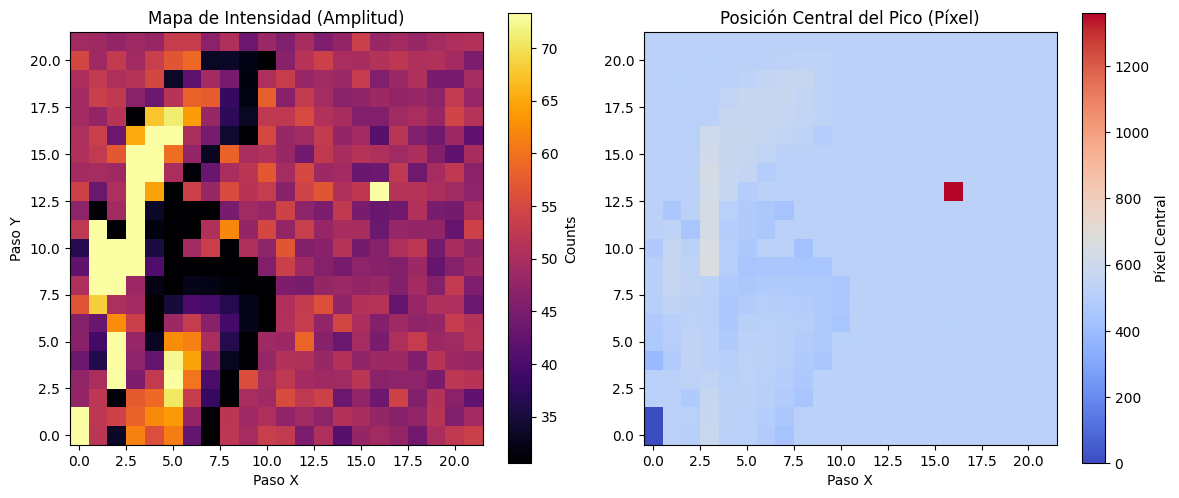

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

limit_up = np.nanpercentile(intensity_map, 95)
limit_down = np.nanpercentile(intensity_map, 5)

im1 = ax1.imshow(intensity_map, cmap='inferno', origin='lower', vmax=limit_up, vmin=limit_down)
ax1.set_title("Mapa de Intensidad (Amplitud)")
ax1.set_xlabel("Paso X")
ax1.set_ylabel("Paso Y")
fig.colorbar(im1, ax=ax1, label="Counts")

# --- Mapa 2: Posición del Pico (Desplazamiento / Strain) ---
# Usamos un colormap divergente como 'coolwarm' para ver giros hacia el rojo o azul
im2 = ax2.imshow(position_map, cmap='coolwarm', origin='lower')
ax2.set_title("Posición Central del Pico (Píxel)")
ax2.set_xlabel("Paso X")
fig.colorbar(im2, ax=ax2, label="Píxel Central")

plt.tight_layout()
plt.show()


--- RESULTADOS DEL DIAGNÓSTICO ---
Puntuación R^2: 0.6622 (Ideal es 1.0. Menos de 0.8 es sospechoso)
Posición del pico (x0): 0.17 ± 0.226 píxeles


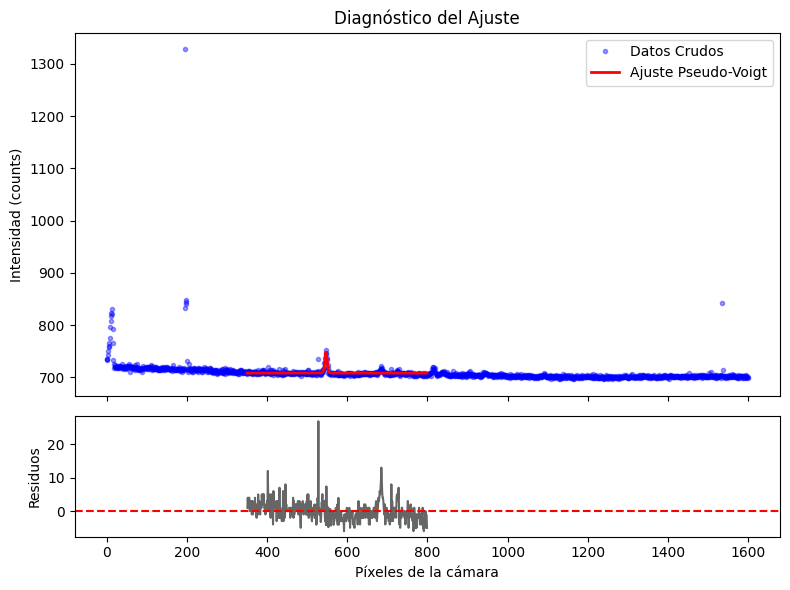

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Extraemos el espectro del punto que queremos evaluar
y_data = y_matrix[4,2, :]
y_plantilla = medfilt(y_data, kernel_size=25)
dif=y_data-y_plantilla
noise_treshold=50
mask=dif>noise_treshold

y_limpio = y_data.copy()             # 1. Hacemos una copia entera del original (1600 px)
y_limpio[mask] = y_plantilla[mask]   # 2. Le ponemos la "tirita" solo a los 7 malos
y_zone = y_limpio[filtro]            # 3. Ahora sí, recortamos la ventana (ROI)
x_zone=x_data[filtro]
# Calculamos cómo se vería la curva ideal generada con los parámetros óptimos
a,x,popt,pcov = peak_track(x_zone, y_zone)
y_fit = pv(x_zone,*popt)
# --- PRUEBA 1: R-CUADRADO (R^2) ---
# Compara el error del ajuste con la varianza natural de los datos
residuos = y_zone - y_fit
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y_zone - np.mean(y_data))**2)
r_cuadrado = 1 - (ss_res / ss_tot)

# --- PRUEBA 2: ERROR DE LOS PARÁMETROS ---
# La diagonal de pcov nos da la varianza. La raíz cuadrada es el error estándar (1 sigma)
errores = np.sqrt(np.diag(pcov))
error_x0 = errores[1] # popt[1] era x0, así que errores[1] es el error de x0

print(f"--- RESULTADOS DEL DIAGNÓSTICO ---")
print(f"Puntuación R^2: {r_cuadrado:.4f} (Ideal es 1.0. Menos de 0.8 es sospechoso)")
print(f"Posición del pico (x0): {popt[1]:.2f} ± {error_x0:.3f} píxeles")

# --- PRUEBA 3: INSPECCIÓN VISUAL (Gráfico de Residuos) ---
# Dibujamos dos gráficos pegados: arriba la curva, abajo lo que sobra (residuos)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Gráfico superior: Datos vs Ajuste
ax1.plot(x_data, y_data, 'b.', label='Datos Crudos', alpha=0.4)
ax1.plot(x_zone, y_fit, 'r-', label='Ajuste Pseudo-Voigt', linewidth=2)
ax1.set_ylabel("Intensidad (counts)")
ax1.legend()
ax1.set_title("Diagnóstico del Ajuste")

# Gráfico inferior: Residuos
ax2.plot(x_zone, residuos, 'k-', alpha=0.6)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_ylabel("Residuos")
ax2.set_xlabel("Píxeles de la cámara")

plt.tight_layout()
plt.show()